In [1]:
import pandas as pd
df=pd.read_csv('netflix_cleaned3.csv')

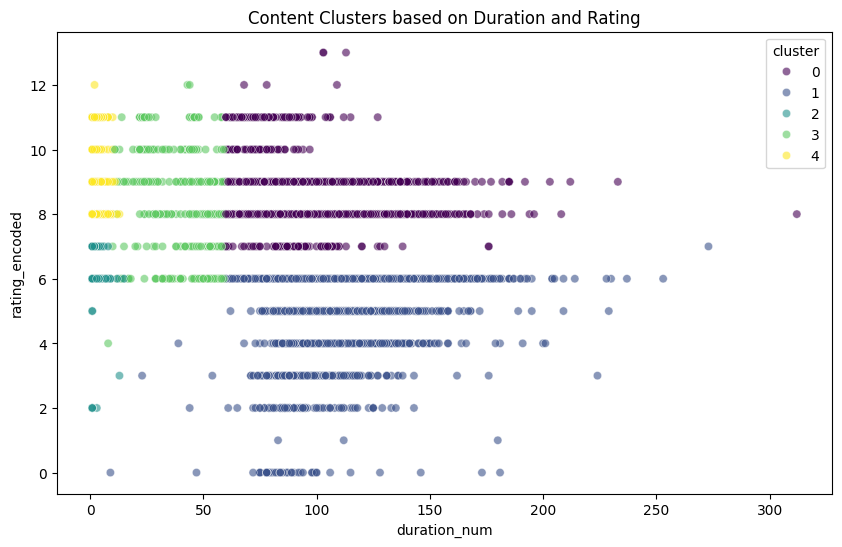

--- Clustering Complete ---
                              title  cluster
0              Dick Johnson Is Dead        1
1                     Blood & Water        4
2                         Ganglands        4
3             Jailbirds New Orleans        4
4                      Kota Factory        4
5                     Midnight Mass        4
6  My Little Pony: A New Generation        1
7                           Sankofa        0
8     The Great British Baking Show        2
9                      The Starling        1


In [2]:

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns



# 2. Prepare Features for Clustering
# We will use 'type', 'rating', 'duration_num', and 'Length_Category'
# We use Label Encoding to turn text categories into numbers
le = LabelEncoder()
df['type_encoded'] = le.fit_transform(df['type'])
df['rating_encoded'] = le.fit_transform(df['rating'])
df['len_cat_encoded'] = le.fit_transform(df['Length_Category'])

# 3. Select and Scale the Data
# Clustering is sensitive to the scale of numbers (e.g., 90 mins vs 1 season)
features = df[['type_encoded', 'rating_encoded', 'duration_num', 'len_cat_encoded']]
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# 4. Apply K-Means Clustering
# We will start by creating 5 clusters (groups) of similar content
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(scaled_features)

# 5. Visualize the Clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df, 
    x='duration_num', 
    y='rating_encoded', 
    hue='cluster', 
    palette='viridis',
    alpha=0.6
)
plt.title('Content Clusters based on Duration and Rating')
plt.show()

print("--- Clustering Complete ---")
print(df[['title', 'cluster']].head(10))

In [3]:
# Save the dataset including the new cluster labels for the dashboard phase
df.to_csv('netflix_clustered.csv', index=False)
print("Clustered dataset saved as 'netflix_clustered.csv'")

Clustered dataset saved as 'netflix_clustered.csv'


In [5]:

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   show_id          8790 non-null   object
 1   type             8790 non-null   object
 2   title            8790 non-null   object
 3   director         8790 non-null   object
 4   cast             8790 non-null   object
 5   country          8790 non-null   object
 6   date_added       8790 non-null   object
 7   release_year     8790 non-null   int64 
 8   rating           8790 non-null   object
 9   duration         8790 non-null   object
 10  listed_in        8790 non-null   object
 11  description      8790 non-null   object
 12  duration_num     8790 non-null   int64 
 13  duration_unit    8790 non-null   object
 14  Length_Category  8790 non-null   object
 15  year_added       8790 non-null   int64 
 16  Content_Source   8790 non-null   object
 17  type_encoded     8790 non-null   

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,...,description,duration_num,duration_unit,Length_Category,year_added,Content_Source,type_encoded,rating_encoded,len_cat_encoded,cluster
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,...,"As her father nears the end of his life, filmm...",90,min,Average Movie,2021,Licensed,0,4,0,1
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,...,"After crossing paths at a party, a Cape Town t...",2,Seasons,Multi-Season,2021,Likely Original,1,8,2,4
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,...,To protect his family from a powerful drug lor...,1,Season,Single Season,2021,Likely Original,1,8,4,4
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,...,"Feuds, flirtations and toilet talk go down amo...",1,Season,Single Season,2021,Likely Original,1,8,4,4
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,...,In a city of coaching centers known to train I...,2,Seasons,Multi-Season,2021,Likely Original,1,8,2,4


In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the data prepared in the clustering step
df = pd.read_csv('netflix_clustered.csv')

# 2. Define Features (X) and Target (y)
# We are trying to predict 'type' (Movie vs TV Show)
# We use the encoded versions of rating and length category
X = df[['rating_encoded', 'duration_num', 'len_cat_encoded']] 
y = df['type']

# 3. Split data into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Initialize and Train the Random Forest Classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# 5. Evaluate the Model
y_pred = clf.predict(X_test)
print("--- Classification Results ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred))

--- Classification Results ---
Accuracy: 100.00%

Detailed Report:
              precision    recall  f1-score   support

       Movie       1.00      1.00      1.00      1227
     TV Show       1.00      1.00      1.00       531

    accuracy                           1.00      1758
   macro avg       1.00      1.00      1.00      1758
weighted avg       1.00      1.00      1.00      1758



C:\Users\alinv\AppData\Local\Temp\ipykernel_25840\1345574935.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')


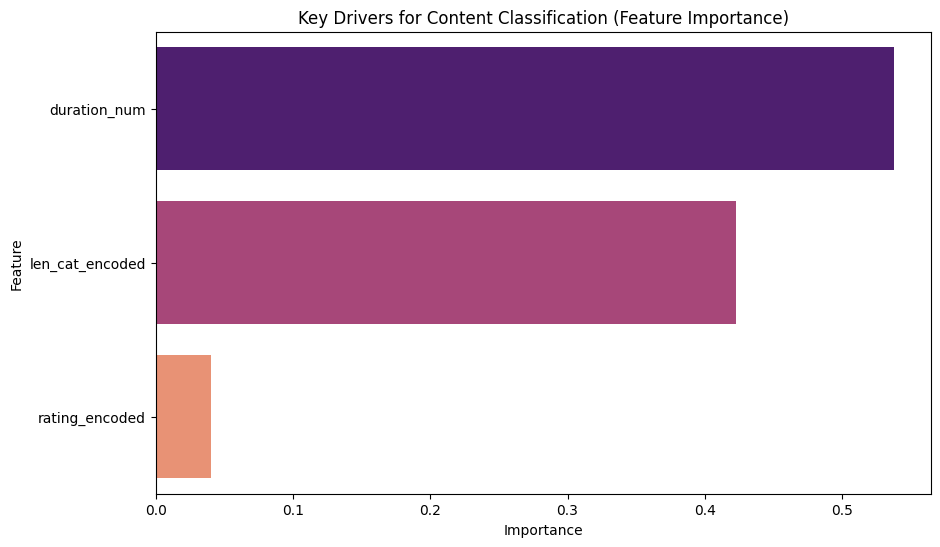

--- Feature Importance Analysis ---
           Feature  Importance
1     duration_num     0.53775
2  len_cat_encoded     0.42238
0   rating_encoded     0.03987


In [7]:
# 1. Extract Feature Importances
importances = clf.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# 2. Visualize Feature Importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')
plt.title('Key Drivers for Content Classification (Feature Importance)')
plt.show()

print("--- Feature Importance Analysis ---")
print(feature_importance_df)

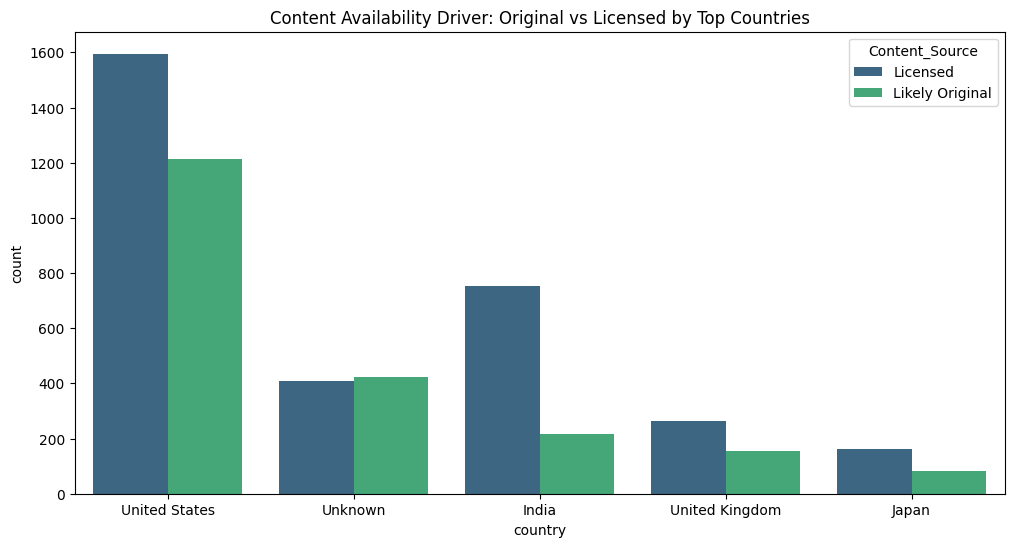

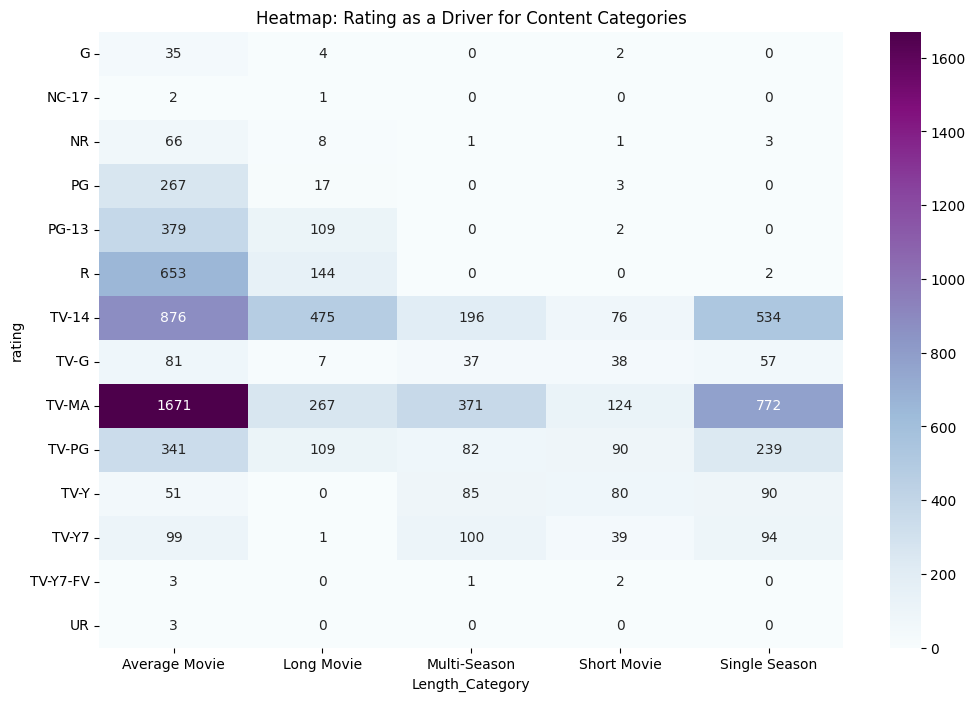

--- Availability Analysis Complete ---


In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load your latest data
df = pd.read_csv('netflix_clustered.csv')

# 2. Analyze Genre Availability by Country (Key Driver Analysis)
# Let's look at the Top 5 countries and their most common Content Source
top_countries = df['country'].value_counts().head(5).index
availability_analysis = df[df['country'].isin(top_countries)]

plt.figure(figsize=(12, 6))
sns.countplot(data=availability_analysis, x='country', hue='Content_Source', palette='viridis')
plt.title('Content Availability Driver: Original vs Licensed by Top Countries')
plt.show()

# 3. Analyze Rating Drivers for Genres
# Does the Rating drive the Genre availability?
genre_rating = df.groupby(['rating', 'Length_Category']).size().unstack().fillna(0)
plt.figure(figsize=(12, 8))
sns.heatmap(genre_rating, annot=True, fmt='g', cmap='BuPu')
plt.title('Heatmap: Rating as a Driver for Content Categories')
plt.show()

print("--- Availability Analysis Complete ---")




In [9]:
# Save the final dataset with all engineered features and cluster labels
df.to_csv('netflix_final_analysis.csv', index=False)

print("Final analysis dataset saved successfully as 'netflix_final_analysis.csv'!")

Final analysis dataset saved successfully as 'netflix_final_analysis.csv'!
